# HHT Epidemiology: Initial Exploratory Analysis

Initial exploratory analysis of the merged analysis dataframe built by `Merging_tables.ipynb`
(`bq_exports/cleaned/analytic_df.rds`), covering cohort demographics, prevalence of key
complications, medication use, procedures, geographic/socioeconomic distribution, and a
first look at diagnosis timing (a proxy for incidence).

**Note on cell counts:** this is exploratory, within-workspace analysis. Before any counts
leave the workspace (posters, papers, presentations), apply the All of Us cell-size
suppression policy (counts < 20 must be suppressed or aggregated).


In [10]:
install.packages("CreateTableOne")
library(tidyverse)
library(scales)
library(CreateTableOne)

options(repr.plot.width = 9, repr.plot.height = 5)

# Single consistent hue for ranked/magnitude bar charts (dataviz best practice:
# sequential = one hue light->dark; color is reserved for identity, not used here
# since every chart below is "count by category", i.e. a magnitude comparison).
bar_fill <- "#2a78d6"

theme_epi <- theme_minimal(base_size = 12) +
  theme(
    panel.grid.minor = element_blank(),
    plot.title = element_text(face = "bold"),
    plot.subtitle = element_text(color = "grey30"),
    axis.title.y = element_blank()
  )


Warning message:
“package ‘CreateTableOne’ is not available for this version of R

A version of this package for your version of R might be available elsewhere,
see the ideas at
https://cran.r-project.org/doc/manuals/r-patched/R-admin.html#Installing-packages”


ERROR: Error in library(CreateTableOne): there is no package called ‘CreateTableOne’


In [3]:
cleaned_dir <- file.path(Sys.getenv("HOME"), "workspace", "hht-epi-bucket", "bq_exports", "cleaned")

analytic_df <- readRDS(file.path(cleaned_dir, "analytic_df.rds"))
person_df   <- readRDS(file.path(cleaned_dir, "person.rds")) %>%
  distinct(person_id, .keep_all = TRUE)

cohort_n <- n_distinct(person_df$person_id)

cat("analytic_df:", nrow(analytic_df), "rows x", ncol(analytic_df), "columns\n")
cat("Full HHT cohort (person.rds):", comma(cohort_n), "people\n")
cat("People with >=1 qualifying condition/procedure/drug event:",
    comma(n_distinct(analytic_df$person_id)), "people\n")

glimpse(analytic_df)


analytic_df: 130780 rows x 29 columns
Full HHT cohort (person.rds): 1,264 people
People with >=1 qualifying condition/procedure/drug event: 602 people
Rows: 130,780
Columns: 29
$ person_id                         <dbl> 1407663, 1407663, 1407663, 1407663, …
$ domain                            <chr> "condition", "condition", "condition…
$ concept_name                      <chr> "Hemolytic anemia caused by drugs", …
$ source_vocabulary                 <chr> "SNOMED", "SNOMED", "SNOMED", "SNOME…
$ source_concept_code               <chr> "81711008", "81711008", "81711008", …
$ event_date                        <date> 2013-04-24, 2013-04-24, 2013-05-06,…
$ birth_datetime                    <chr> "1957-06-15 00:00:00 UTC", "1957-06-…
$ ethnicity_concept_id              <dbl> 38003563, 38003563, 38003563, 380035…
$ T_DISP_ethnicity                  <chr> "Hispanic or Latino", "Hispanic or L…
$ gender_concept_id                 <dbl> 45878463, 45878463, 45878463, 458784…
$ T_DISP_gender        

## Cohort overview

How many people and events fall into each domain, and what fraction of the full cohort each domain's events actually touch.

domain,n_events,n_persons,pct_of_cohort
<chr>,<int>,<int>,<dbl>
condition,104368,502,39.7
drug,24280,303,24.0
procedure,2132,154,12.2


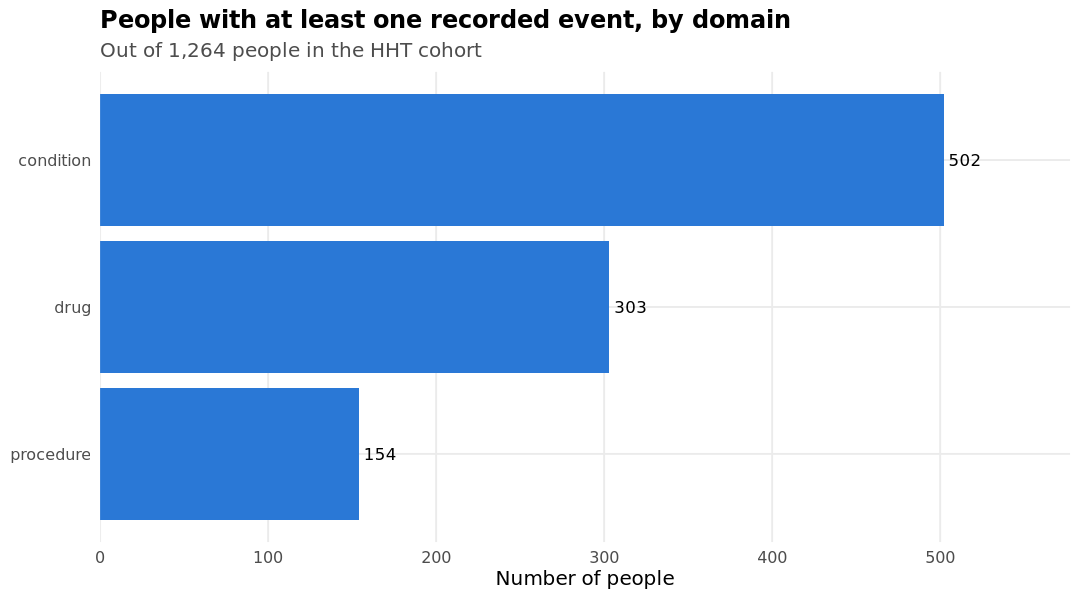

In [4]:
domain_overview <- analytic_df %>%
  group_by(domain) %>%
  summarise(
    n_events = n(),
    n_persons = n_distinct(person_id),
    .groups = "drop"
  ) %>%
  mutate(pct_of_cohort = round(100 * n_persons / cohort_n, 1)) %>%
  arrange(desc(n_persons))

domain_overview

ggplot(domain_overview, aes(x = reorder(domain, n_persons), y = n_persons)) +
  geom_col(fill = bar_fill) +
  coord_flip() +
  geom_text(aes(label = comma(n_persons)), hjust = -0.15, size = 3.5) +
  scale_y_continuous(labels = comma, expand = expansion(mult = c(0, 0.15))) +
  labs(title = "People with at least one recorded event, by domain",
       subtitle = paste0("Out of ", comma(cohort_n), " people in the HHT cohort"),
       x = NULL, y = "Number of people") +
  theme_epi


## Optional: only keep those with an HHT diagnosis


In [7]:
hht_only <- analytic_df %>% filter(concept_name == "Osler hemorrhagic telangiectasia syndrome")
hht_only <- hht_only$person_id
analytic_df <- analytic_df %>%
  filter(person_id %in% hht_only)
person_df <- person_df %>% filter(person_id %in% hht_only)

## Cohort demographics

### Cleaning

In [ ]:
person_df <- person_df %>% mutate(
    T_DISP_gender = ifelse(T_DISP_gender %in% c("Female", "Male"), T_DISP_gender, "Other/Skip"),
    T_DISP_sex_at_birth = ifelse(T_DISP_sex_at_birth %in% c("Female", "Male"), T_DISP_sex_at_birth, "Other/Skip"),
    T_DISP_race = case_when(
      str_detect(T_DISP_race, regex("white|black|asian", ignore_case = TRUE)) ~ T_DISP_race,
      TRUE ~ "Other/Skip"
    ),
    T_DISP_ethnicity = case_when(
      str_detect(T_DISP_ethnicity, regex("Hispanic", ignore_case = TRUE)) ~ T_DISP_ethnicity,
      TRUE ~ "Other/Skip"
    ),
    )

T_DISP_gender,n,pct
<chr>,<int>,<dbl>
Female,797,63.1
Male,444,35.1
PMI: Skip,8,0.6
Gender Identity: Non Binary,7,0.6
"Not man only, not woman only, prefer not to answer, or skipped",4,0.3
I prefer not to answer,2,0.2
Gender Identity: Additional Options,1,0.1
Gender Identity: Transgender,1,0.1


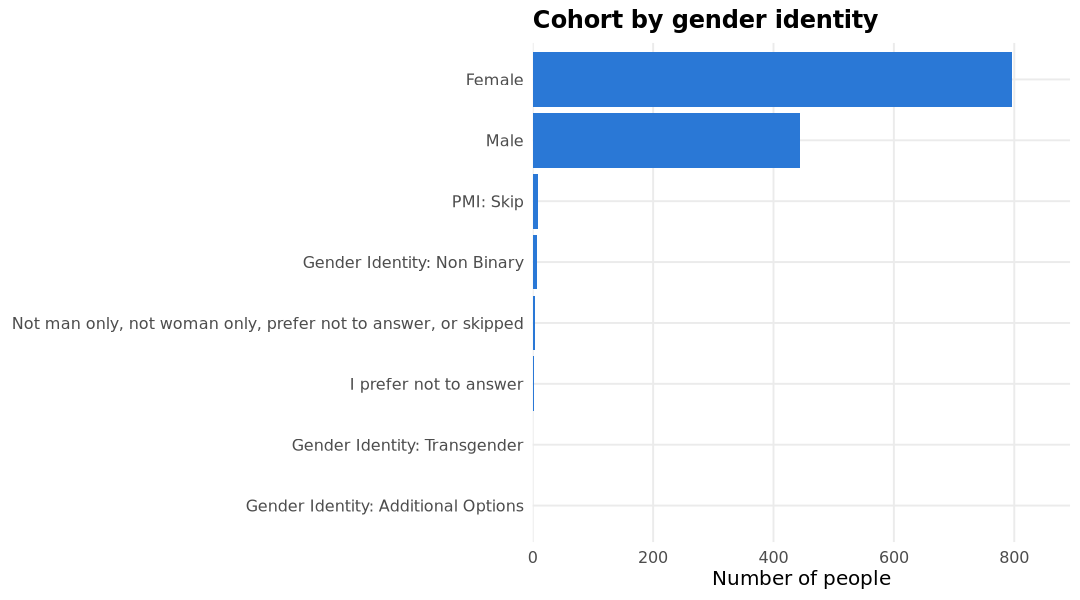

In [5]:
gender_summary <- person_df %>%
  count(T_DISP_gender, name = "n") %>%
  mutate(pct = round(100 * n / sum(n), 1)) %>%
  arrange(desc(n))

gender_summary

ggplot(gender_summary, aes(x = reorder(T_DISP_gender, n), y = n)) +
  geom_col(fill = bar_fill) +
  coord_flip() +
  scale_y_continuous(labels = comma, expand = expansion(mult = c(0, 0.12))) +
  labs(title = "Cohort by gender identity", x = NULL, y = "Number of people") +
  theme_epi


T_DISP_race,n,pct
<chr>,<int>,<dbl>
White,748,59.2
Black or African American,179,14.2
None Indicated,178,14.1
More than one population,60,4.7
Asian,35,2.8
PMI: Skip,19,1.5
American Indian or Alaska Native,17,1.3
None of these,14,1.1
Middle Eastern or North African,7,0.6


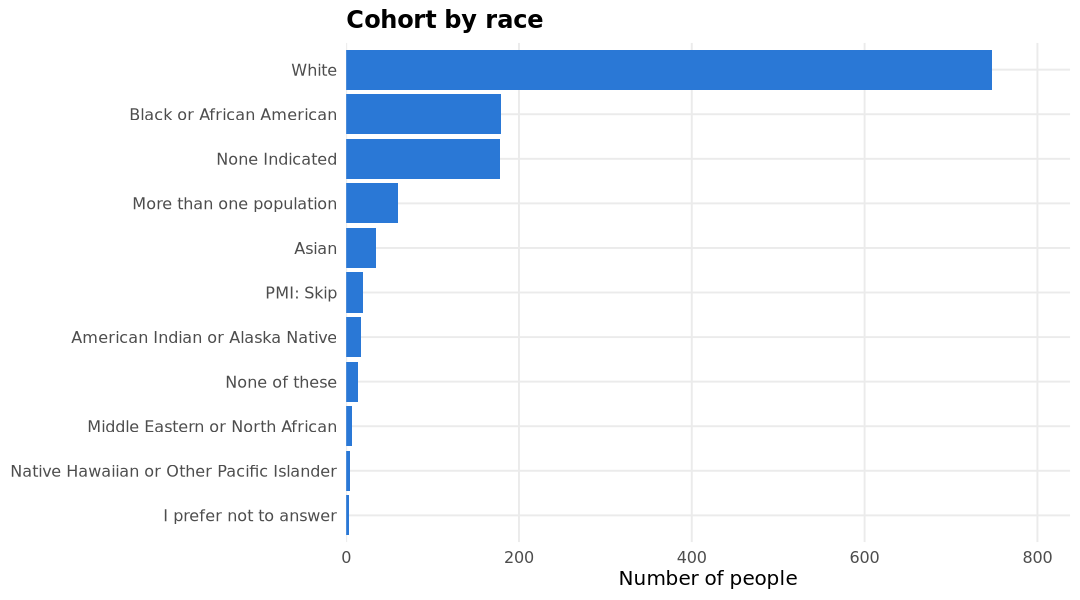

In [6]:
race_summary <- person_df %>%
  count(T_DISP_race, name = "n") %>%
  mutate(pct = round(100 * n / sum(n), 1)) %>%
  arrange(desc(n))

race_summary

ggplot(race_summary, aes(x = reorder(T_DISP_race, n), y = n)) +
  geom_col(fill = bar_fill) +
  coord_flip() +
  scale_y_continuous(labels = comma, expand = expansion(mult = c(0, 0.12))) +
  labs(title = "Cohort by race", x = NULL, y = "Number of people") +
  theme_epi


T_DISP_ethnicity,n,pct
<chr>,<int>,<dbl>
Not Hispanic or Latino,999,79.0
Hispanic or Latino,229,18.1
PMI: Skip,19,1.5
What Race Ethnicity: Race Ethnicity None Of These,14,1.1
PMI: Prefer Not To Answer,3,0.2


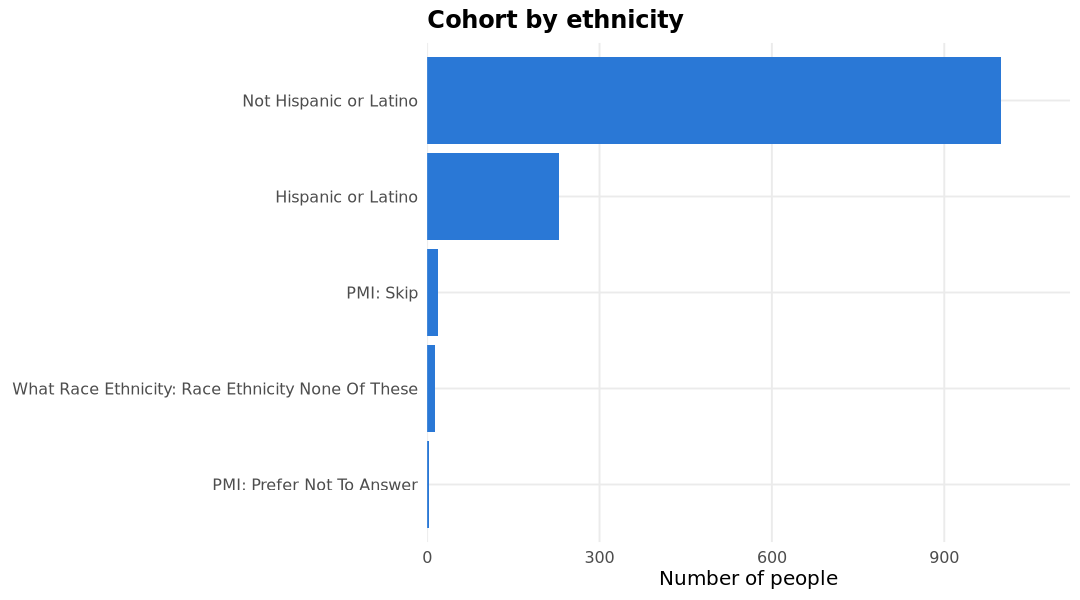

In [7]:
ethnicity_summary <- person_df %>%
  count(T_DISP_ethnicity, name = "n") %>%
  mutate(pct = round(100 * n / sum(n), 1)) %>%
  arrange(desc(n))

ethnicity_summary

ggplot(ethnicity_summary, aes(x = reorder(T_DISP_ethnicity, n), y = n)) +
  geom_col(fill = bar_fill) +
  coord_flip() +
  scale_y_continuous(labels = comma, expand = expansion(mult = c(0, 0.12))) +
  labs(title = "Cohort by ethnicity", x = NULL, y = "Number of people") +
  theme_epi


Age (years) summary:
   Min. 1st Qu.  Median    Mean 3rd Qu.    Max. 
  21.18   43.93   60.18   58.10   72.18  103.18 


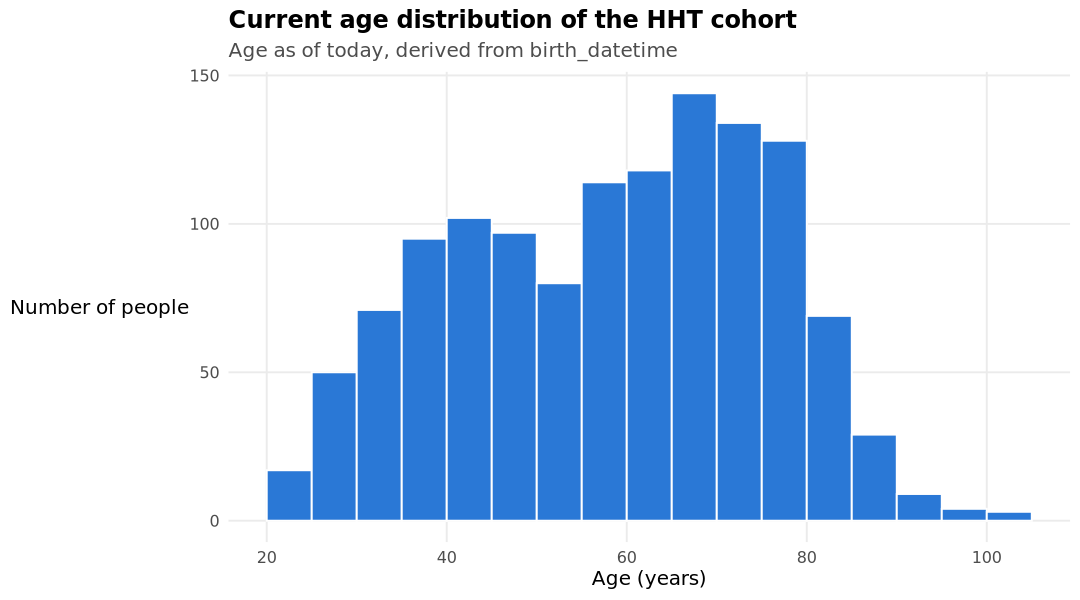

In [8]:
age_df <- person_df %>%
  mutate(
    birth_date = as.Date(birth_datetime),
    age_years = as.numeric(difftime(Sys.Date(), birth_date, units = "days")) / 365.25
  )

cat("Age (years) summary:\n")
print(summary(age_df$age_years))

ggplot(age_df, aes(x = age_years)) +
  geom_histogram(binwidth = 5, fill = bar_fill, color = "white", boundary = 0) +
  labs(title = "Current age distribution of the HHT cohort",
       subtitle = "Age as of today, derived from birth_datetime",
       x = "Age (years)", y = "Number of people") +
  theme_epi + theme(axis.title.y = element_text())


## Prevalence of symptoms & complications

Within-cohort prevalence: the share of the HHT cohort with at least one recorded instance of
each condition. `Osler hemorrhagic telangiectasia syndrome` is the cohort-defining diagnosis
itself, included here as a check on how many people have a *coded* HHT diagnosis versus
qualifying only via the ENG/ACVRL1 genetic-variant pathway.

# A tibble: 102 × 3
   concept_name                                        n_persons pct_of_cohort
   <chr>                                                   <int>         <dbl>
 1 Anemia                                                    283          22.4
 2 Osler hemorrhagic telangiectasia syndrome                 260          20.6
 3 Iron deficiency anemia                                    164          13  
 4 Bleeding from nose                                        119           9.4
 5 Hemorrhage of rectum and anus                              86           6.8
 6 Iron deficiency anemia due to blood loss                   80           6.3
 7 Iron deficiency                                            72           5.7
 8 Gastrointestinal hemorrhage                                59           4.7
 9 Acute posthemorrhagic anemia                               52           4.1
10 Anemia of chronic disease                                  37           2.9
11 Anemia due to chronic blood l

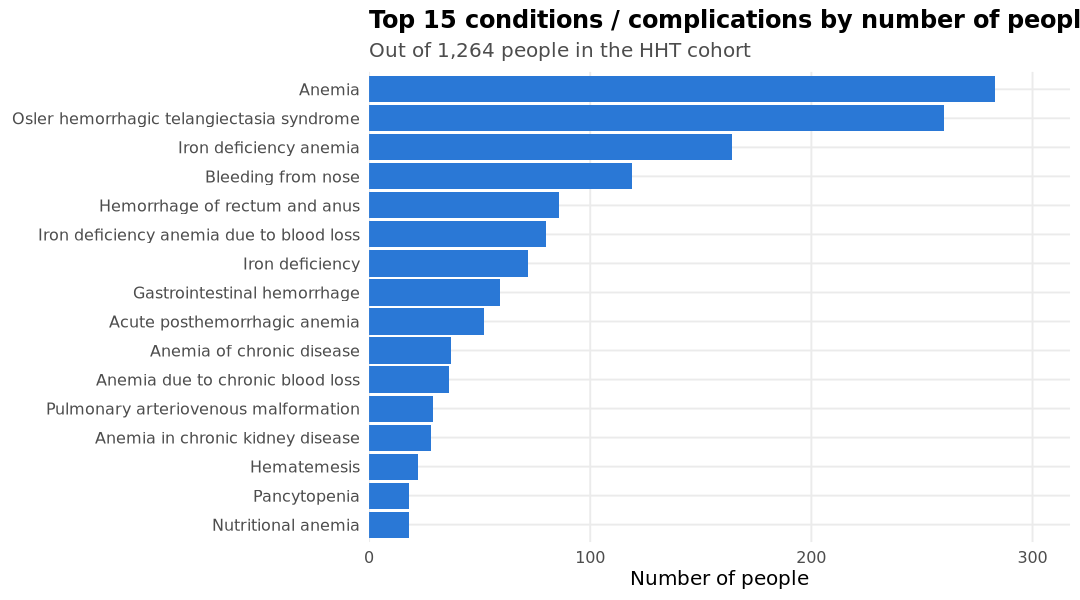

In [9]:
condition_summary <- analytic_df %>%
  filter(domain == "condition") %>%
  distinct(person_id, concept_name) %>%
  count(concept_name, name = "n_persons") %>%
  mutate(pct_of_cohort = round(100 * n_persons / cohort_n, 1)) %>%
  arrange(desc(n_persons))

print(condition_summary, n = 20)

condition_summary %>%
  slice_max(n_persons, n = 15) %>%
  ggplot(aes(x = reorder(concept_name, n_persons), y = n_persons)) +
  geom_col(fill = bar_fill) +
  coord_flip() +
  scale_y_continuous(labels = comma, expand = expansion(mult = c(0, 0.12))) +
  labs(title = "Top 15 conditions / complications by number of people affected",
       subtitle = paste0("Out of ", comma(cohort_n), " people in the HHT cohort"),
       x = NULL, y = "Number of people") +
  theme_epi


## Medication use

Grouped to the ingredient level (each drug/dose/brand row in `analytic_df` is bucketed by the
active ingredient it corresponds to) so this reflects *people exposed to each medication*,
not distinct product strings.

ingredient,n_persons,pct_of_cohort
<chr>,<int>,<dbl>
Iron supplementation,193,15.3
Folic acid,129,10.2
Tranexamic acid,70,5.5
Bevacizumab,11,0.9
Pomalidomide,2,0.2


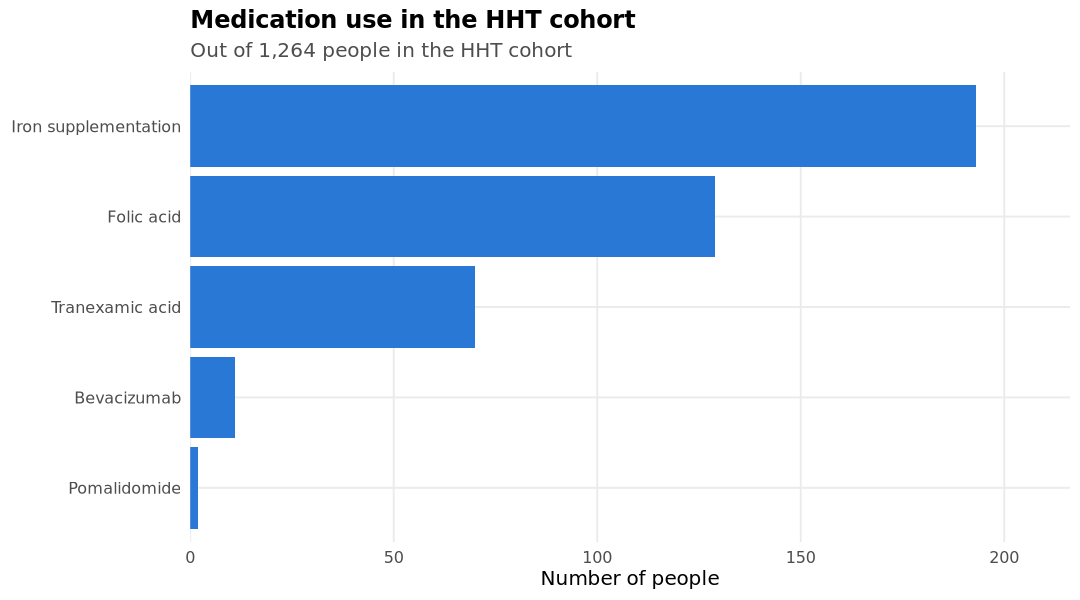

In [10]:
drug_summary <- analytic_df %>%
  filter(domain == "drug") %>%
  mutate(ingredient = case_when(
    str_detect(concept_name, regex("bevacizumab", ignore_case = TRUE))    ~ "Bevacizumab",
    str_detect(concept_name, regex("pomalidomide", ignore_case = TRUE))   ~ "Pomalidomide",
    str_detect(concept_name, regex("tranexamic", ignore_case = TRUE))     ~ "Tranexamic acid",
    str_detect(concept_name, regex("folic acid", ignore_case = TRUE))     ~ "Folic acid",
    str_detect(concept_name, regex("iron|ferrous", ignore_case = TRUE))   ~ "Iron supplementation",
    TRUE ~ "Other"
  )) %>%
  distinct(person_id, ingredient) %>%
  count(ingredient, name = "n_persons") %>%
  mutate(pct_of_cohort = round(100 * n_persons / cohort_n, 1)) %>%
  arrange(desc(n_persons))

drug_summary

ggplot(drug_summary, aes(x = reorder(ingredient, n_persons), y = n_persons)) +
  geom_col(fill = bar_fill) +
  coord_flip() +
  scale_y_continuous(labels = comma, expand = expansion(mult = c(0, 0.12))) +
  labs(title = "Medication use in the HHT cohort",
       subtitle = paste0("Out of ", comma(cohort_n), " people in the HHT cohort"),
       x = NULL, y = "Number of people") +
  theme_epi


## Procedures

concept_name,n_persons,pct_of_cohort
<chr>,<int>,<dbl>
Colonoscopy,99,7.8
Screening colonoscopy,47,3.7
Esophagogastroduodenoscopy,19,1.5
Endoscopy and biopsy of upper gastrointestinal tract,16,1.3
Flexible fiberoptic sigmoidoscopy with biopsy,10,0.8
Packed blood cell transfusion,8,0.6
Flexible fiberoptic sigmoidoscopy,6,0.5
Colonoscopy and biopsy of colon,3,0.2
Flexible fiberoptic sigmoidoscopy for removal of foreign body,1,0.1


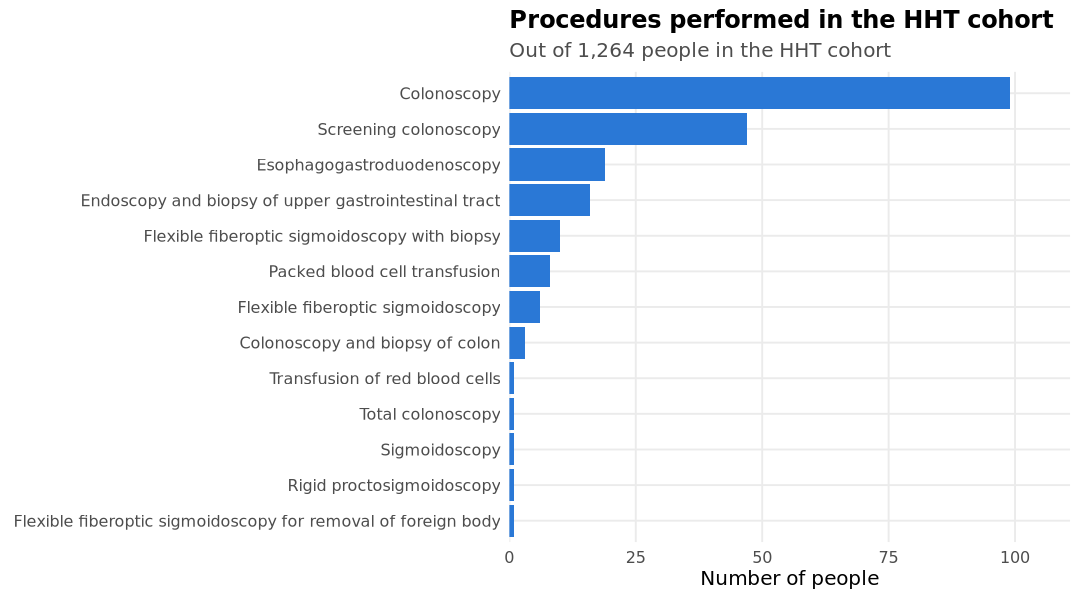

In [11]:
procedure_summary <- analytic_df %>%
  filter(domain == "procedure") %>%
  distinct(person_id, concept_name) %>%
  count(concept_name, name = "n_persons") %>%
  mutate(pct_of_cohort = round(100 * n_persons / cohort_n, 1)) %>%
  arrange(desc(n_persons))

procedure_summary

ggplot(procedure_summary, aes(x = reorder(concept_name, n_persons), y = n_persons)) +
  geom_col(fill = bar_fill) +
  coord_flip() +
  scale_y_continuous(labels = comma, expand = expansion(mult = c(0, 0.12))) +
  labs(title = "Procedures performed in the HHT cohort",
       subtitle = paste0("Out of ", comma(cohort_n), " people in the HHT cohort"),
       x = NULL, y = "Number of people") +
  theme_epi


## Geographic distribution & socioeconomic status

`zip_code`, `deprivation_index`, and `median_income` come from the zip-code-level
American Community Survey linkage; each person's most recent survey year was kept during
merging, so these are one value per person (not one per event).

People with linked zip-code / SES data: 578 out of 1,264 


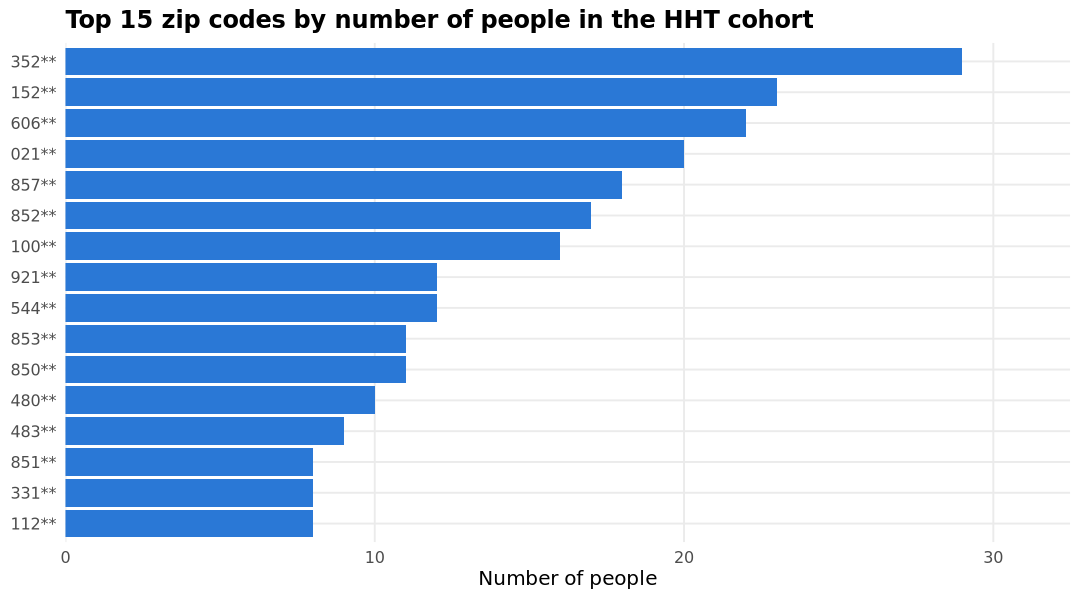

In [12]:
zip_person <- analytic_df %>%
  filter(!is.na(zip_code)) %>%
  distinct(person_id, zip_code, deprivation_index, median_income, poverty, no_health_insurance)

cat("People with linked zip-code / SES data:", comma(n_distinct(zip_person$person_id)),
    "out of", comma(cohort_n), "\n")

zip_person %>%
  count(zip_code, name = "n_persons") %>%
  arrange(desc(n_persons)) %>%
  slice_max(n_persons, n = 15) %>%
  ggplot(aes(x = reorder(zip_code, n_persons), y = n_persons)) +
  geom_col(fill = bar_fill) +
  coord_flip() +
  scale_y_continuous(labels = comma, expand = expansion(mult = c(0, 0.12))) +
  labs(title = "Top 15 zip codes by number of people in the HHT cohort",
       x = NULL, y = "Number of people") +
  theme_epi


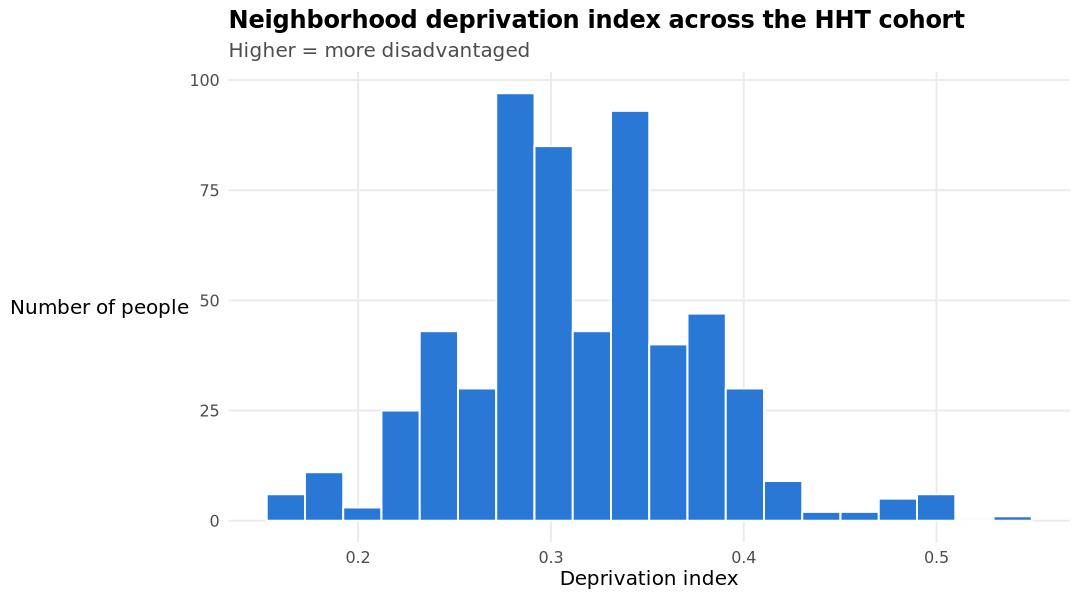

In [13]:
ggplot(zip_person, aes(x = deprivation_index)) +
  geom_histogram(bins = 20, fill = bar_fill, color = "white") +
  labs(title = "Neighborhood deprivation index across the HHT cohort",
       subtitle = "Higher = more disadvantaged",
       x = "Deprivation index", y = "Number of people") +
  theme_epi + theme(axis.title.y = element_text())


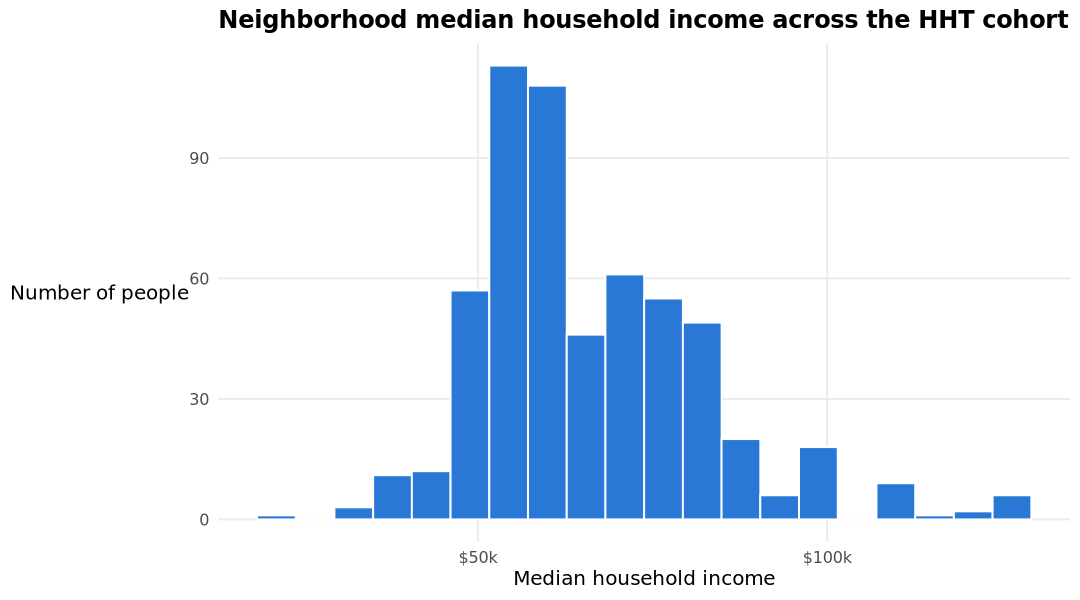

In [14]:
ggplot(zip_person, aes(x = median_income)) +
  geom_histogram(bins = 20, fill = bar_fill, color = "white") +
  scale_x_continuous(labels = dollar_format(scale = 1e-3, suffix = "k")) +
  labs(title = "Neighborhood median household income across the HHT cohort",
       x = "Median household income", y = "Number of people") +
  theme_epi + theme(axis.title.y = element_text())


## First recorded HHT diagnosis over time (incidence proxy)

This is **not** true incidence -- it's the calendar year each person's HHT diagnosis code
first appears in their EHR record, which mixes true new diagnoses with existing patients
newly entering the data source. Useful as a first look at how the cohort has accumulated
over time.

People with a coded HHT diagnosis and a valid date: 260 out of 1,264 in the cohort
(The remainder likely qualified for the cohort via the ENG/ACVRL1 pathogenic-variant
 pathway without [yet] having a coded HHT diagnosis in the EHR.)


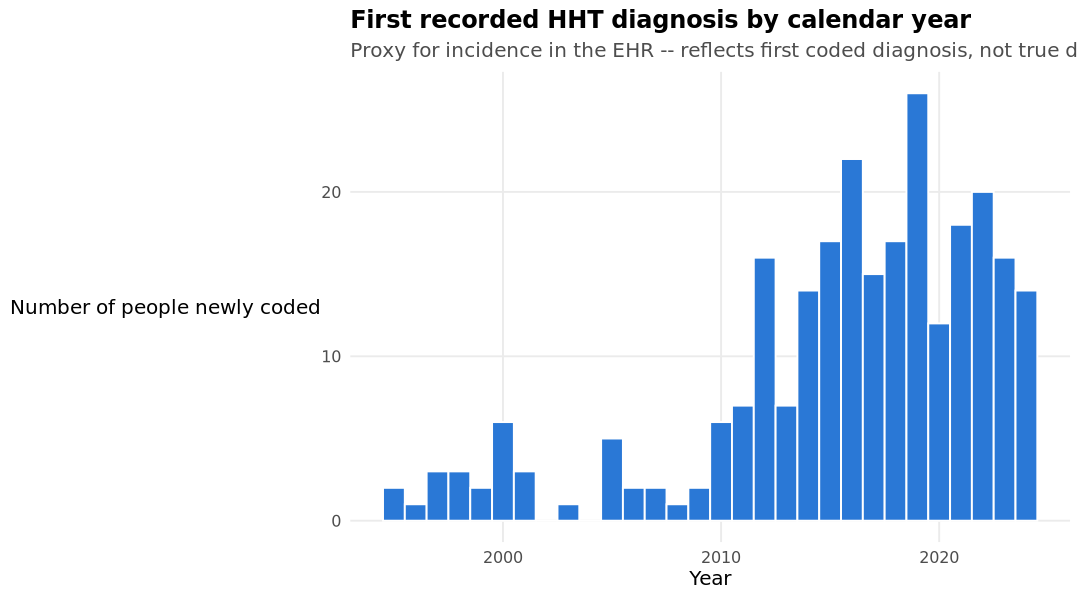

In [15]:
hht_first_dx <- analytic_df %>%
  filter(domain == "condition",
         str_detect(concept_name, regex("Osler|hemorrhagic telangiectasia", ignore_case = TRUE))) %>%
  filter(!is.na(event_date)) %>%
  group_by(person_id) %>%
  summarise(first_dx_date = min(event_date), .groups = "drop") %>%
  mutate(first_dx_year = year(first_dx_date))

cat("People with a coded HHT diagnosis and a valid date:", comma(nrow(hht_first_dx)),
    "out of", comma(cohort_n), "in the cohort\n")
cat("(The remainder likely qualified for the cohort via the ENG/ACVRL1 pathogenic-variant\n",
    " pathway without [yet] having a coded HHT diagnosis in the EHR.)\n", sep = "")

ggplot(hht_first_dx, aes(x = first_dx_year)) +
  geom_histogram(binwidth = 1, fill = bar_fill, color = "white") +
  labs(title = "First recorded HHT diagnosis by calendar year",
       subtitle = "Proxy for incidence in the EHR -- reflects first coded diagnosis, not true disease onset",
       x = "Year", y = "Number of people newly coded") +
  theme_epi + theme(axis.title.y = element_text())


## Summary & next steps

- The cohort is defined by a coded HHT diagnosis and/or a pathogenic ENG/ACVRL1 variant; only
  a subset of the cohort has *any* recorded complication/medication/procedure event in the
  EHR data pulled here -- worth reviewing whether the concept sets in `Get_cohort.ipynb` need
  broadening, and how much of the gap is genuinely undiagnosed/asymptomatic disease.
- Complication and medication prevalence above are **crude, within-cohort** proportions (not
  adjusted for follow-up time or age) -- true incidence/prevalence estimation would need
  person-time denominators and a defined observation window per person.
- Consider stratifying prevalence/medication-use tables by age group, sex, and deprivation
  index/geography to look for disparities.
- Apply the All of Us cell-size suppression policy (counts < 20) before any of these figures
  or tables leave the workspace.
